**PROJECT  --- ELECTRICITY DEMAND FORCASTING**

In [1]:
#importing lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import random

In [2]:
data=pd.read_csv('ElectricityData.csv')

In [3]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,01-Jan-20,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,01-Jan-20,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,01-Jan-20,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,01-Jan-20,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,01-Jan-20,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,31-Dec-24,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,31-Dec-24,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,31-Dec-24,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,31-Dec-24,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [4]:
# Data exploration
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  object 
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.0+ MB


In [5]:
#convert  the col datatype to datatime format

data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d-%b-%y')


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[ns]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 3.0 MB


In [7]:
data

,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
1,2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2,2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
3,2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
4,2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
43843,2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
43844,2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
43845,2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957
43846,2024-12-31,22.0,1.0,12.0,2024.0,366.0,3.000000,51.998107,3353.241682


In [8]:
# set this datetime as index of our dataframe
data=data.set_index('Timestamp')

In [9]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [10]:
#use describe func to check summary stats
data[['Temperature','Humidity','Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [11]:
#DATA CLEANING
#check for missing values
data.isnull().sum()

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64

In [12]:
#to show records that contain  any null val/missing val
data[data.isna().any(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-04-30,NaN,3.0,4.0,2020.0,121.0,21.820261,41.353675,5393.127681
2020-07-21,NaN,1.0,7.0,2020.0,203.0,36.555833,62.779665,6248.349423
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-27,NaN,5.0,2.0,2021.0,58.0,24.001003,53.303268,4523.253789
2021-12-13,23.0,0.0,12.0,2021.0,NaN,3.000000,75.457130,3225.225822
2021-12-14,NaN,1.0,12.0,2021.0,348.0,5.061319,47.215825,2887.848612


In [14]:
# to show records that contain all null val
data[data.isna().all(axis=1)]

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Drop all those records containing all missing values
data=data.dropna(how='all')

In [14]:
data

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [17]:
data.isnull().sum()

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64

In [16]:
# to fill the null values we have in some columns we will use bfill,ffill
# data[['hour','dayofweek','month','year','dayofyear']] = data[['hour','dayofweek','month','year','dayofyear']].ffill

data.loc[:, ['hour','dayofweek','month','year','dayofyear']] = (
    data.loc[:, ['hour','dayofweek','month','year','dayofyear']].ffill()
)



C:\Users\HP\AppData\Local\Temp\ipykernel_16956\1697033142.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, ['hour','dayofweek','month','year','dayofyear']] = (


In [17]:
data.loc[:, ['Temperature','Humidity']] = data.loc[:, ['Temperature','Humidity']].bfill()



C:\Users\HP\AppData\Local\Temp\ipykernel_16956\3652072529.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:, ['Temperature','Humidity']] = data.loc[:, ['Temperature','Humidity']].bfill()


In [18]:
data.loc[:, 'Demand'] = data['Demand'].interpolate(method='time')

In [19]:
data.isnull().sum()

hour           0
dayofweek      0
month          0
year           0
dayofyear      0
Temperature    0
Humidity       0
Demand         0
dtype: int64

In [20]:
data.shape

(43844, 8)

In [21]:
#Feature engineering

#Create quarter column in dataset

data.insert(5,'quarter',data.index.quarter)


In [22]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43844 non-null  float64
 1   dayofweek    43844 non-null  float64
 2   month        43844 non-null  float64
 3   year         43844 non-null  float64
 4   dayofyear    43844 non-null  float64
 5   quarter      43844 non-null  int32  
 6   Temperature  43844 non-null  float64
 7   Humidity     43844 non-null  float64
 8   Demand       43844 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [24]:
data.loc[:,['hour','dayofweek','month','year','dayofyear']]=data[['hour','dayofweek','month','year','dayofyear']].astype(int)

In [25]:
data

,hour,dayofweek,month,year,dayofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [26]:
# Create week of the year
data.insert(5, 'weekofyear', data.index.isocalendar().week.astype(int))


In [27]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,3.000000,40.565916,4015.979957


In [28]:
#create a new column to check the weekend
data.insert(7, 'is_weekend', data.index.dayofweek.isin([5,6]).astype(int))


In [29]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957


In [30]:
data[data['is_weekend']==1]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3.0,5.0,1.0,2020.0,4.0,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4.0,5.0,1.0,2020.0,4.0,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19.0,6.0,12.0,2024.0,364.0,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20.0,6.0,12.0,2024.0,364.0,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21.0,6.0,12.0,2024.0,364.0,52,4,1,3.723222,46.751731,3366.641206


In [31]:
# to check if there is a public holiday or not
# import Holidays package
!pip install holidays



[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import holidays

In [33]:
# specify the country
holidays.IN(years=data.year)

{datetime.date(2020, 1, 26): 'Republic Day', datetime.date(2020, 8, 15): 'Independence Day', datetime.date(2020, 10, 2): 'Gandhi Jayanti', datetime.date(2020, 5, 7): 'Buddha Purnima', datetime.date(2020, 11, 14): 'Diwali', datetime.date(2020, 8, 12): 'Janmashtami', datetime.date(2020, 10, 25): 'Dussehra', datetime.date(2020, 4, 6): 'Mahavir Jayanti', datetime.date(2020, 2, 21): 'Maha Shivaratri', datetime.date(2020, 11, 30): 'Guru Nanak Jayanti', datetime.date(2020, 8, 30): 'Muharram', datetime.date(2020, 10, 30): 'Milad-un-Nabi', datetime.date(2020, 5, 25): 'Id-ul-Fitr', datetime.date(2020, 8, 1): 'Bakrid', datetime.date(2020, 4, 10): 'Good Friday', datetime.date(2020, 12, 25): 'Christmas', datetime.date(2021, 1, 26): 'Republic Day', datetime.date(2021, 8, 15): 'Independence Day', datetime.date(2021, 10, 2): 'Gandhi Jayanti', datetime.date(2021, 5, 26): 'Buddha Purnima', datetime.date(2021, 11, 4): 'Diwali', datetime.date(2021, 8, 30): 'Janmashtami', datetime.date(2021, 10, 15): 'Duss

In [38]:
data.loc[:,'Holidays']=holidays.IN(years=data.year)

In [39]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,Holidays
Timestamp,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,NaN
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,NaN
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,NaN


In [40]:
data=data.drop('Holidays',axis=1)

In [41]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957


In [40]:
# lagged features --- past values of a time series data
# use ---past demand values are strong predictors, they can be used as input  to predict future values

In [42]:
# demand from the same hour yesterday , same hour last week
data['demand_lag_24hrs']=data['Demand'].shift(24)

In [43]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs
Timestamp,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,5102.077310
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,4187.844204
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,3859.260701


In [44]:
data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs
Timestamp,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN
2020-01-01,5.0,2.0,1.0,2020.0,1.0,1,1,0,10.822571,67.753433,3104.845505,NaN
2020-01-01,6.0,2.0,1.0,2020.0,1.0,1,1,0,6.306673,94.912591,3759.476912,NaN
2020-01-01,7.0,2.0,1.0,2020.0,1.0,1,1,0,7.464640,74.456860,4114.486001,NaN
2020-01-01,8.0,2.0,1.0,2020.0,1.0,1,1,0,14.746876,66.725005,4575.159503,NaN


In [45]:
data['Demand_lag_168hrs'] = data['Demand'].shift(168)    #24*7=168hrs

In [46]:
data.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs
Timestamp,,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
2020-01-01,5.0,2.0,1.0,2020.0,1.0,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN
2020-01-01,6.0,2.0,1.0,2020.0,1.0,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN
2020-01-01,7.0,2.0,1.0,2020.0,1.0,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN
2020-01-01,8.0,2.0,1.0,2020.0,1.0,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN


In [48]:
data.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs
Timestamp,,,,,,,,,,,,,
2020-01-07,16.0,1.0,1.0,2020.0,7.0,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17.0,1.0,1.0,2020.0,7.0,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18.0,1.0,1.0,2020.0,7.0,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20.0,1.0,1.0,2020.0,7.0,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21.0,1.0,1.0,2020.0,7.0,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [49]:
# Rolling mean and rolling standard deviation

data['demand_rolling_mean_24hrs']=data['Demand'].rolling(window=24).mean()

In [50]:
data['demand_rolling_std_24hrs']=data['Demand'].rolling(window=24).std()

In [52]:
data['demand_rolling_mean_168hrs']=data['Demand'].rolling(window=168).mean()


In [53]:
data['demand_rolling_std_168hrs']=data['Demand'].rolling(window=168).std()

In [54]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312,3939.391474,973.246610
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615,3937.353242,972.057461
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114,3938.303367,972.055830


In [55]:
# drop all rows having null values
data=data.dropna()

In [56]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,,
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968,3737.113310,974.096125
2020-01-08,1.0,2.0,1.0,2020.0,8.0,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101,3737.188632,973.982477
2020-01-08,2.0,2.0,1.0,2020.0,8.0,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351,3737.055797,974.192732
2020-01-08,3.0,2.0,1.0,2020.0,8.0,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212,3737.261108,973.864974
2020-01-08,4.0,2.0,1.0,2020.0,8.0,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905,3736.845382,974.422879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312,3939.391474,973.246610
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615,3937.353242,972.057461
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114,3938.303367,972.055830


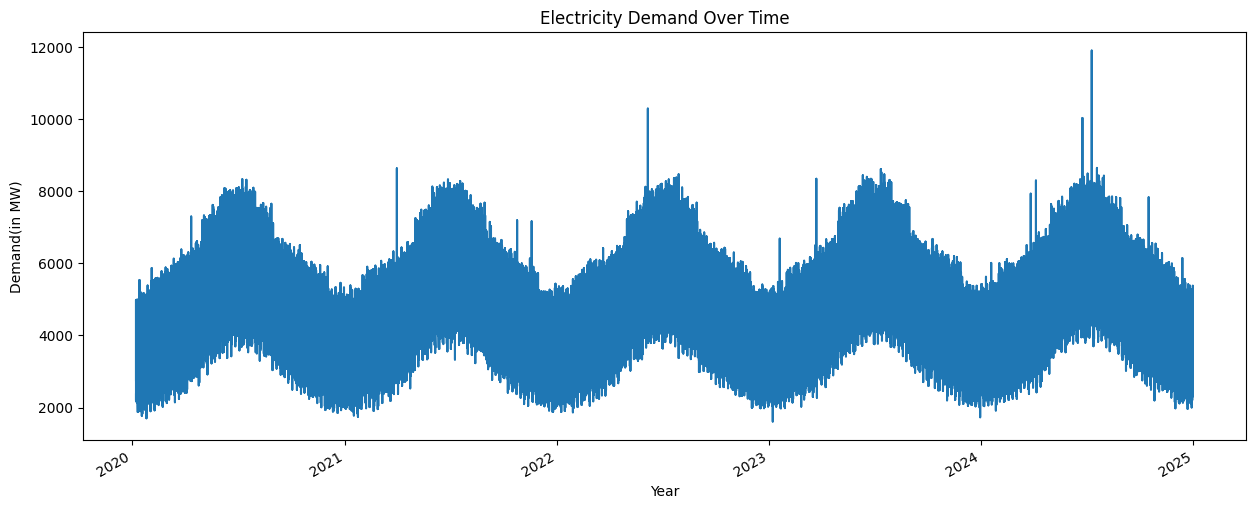

In [57]:
#Visualization
# plot raw demand over time
data['Demand'].plot(figsize=(15,6),title="Electricity Demand Over Time")
plt.xlabel("Year")
plt.ylabel("Demand(in MW)")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_16956\2594320652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='hour', y='Demand', palette='Set3')


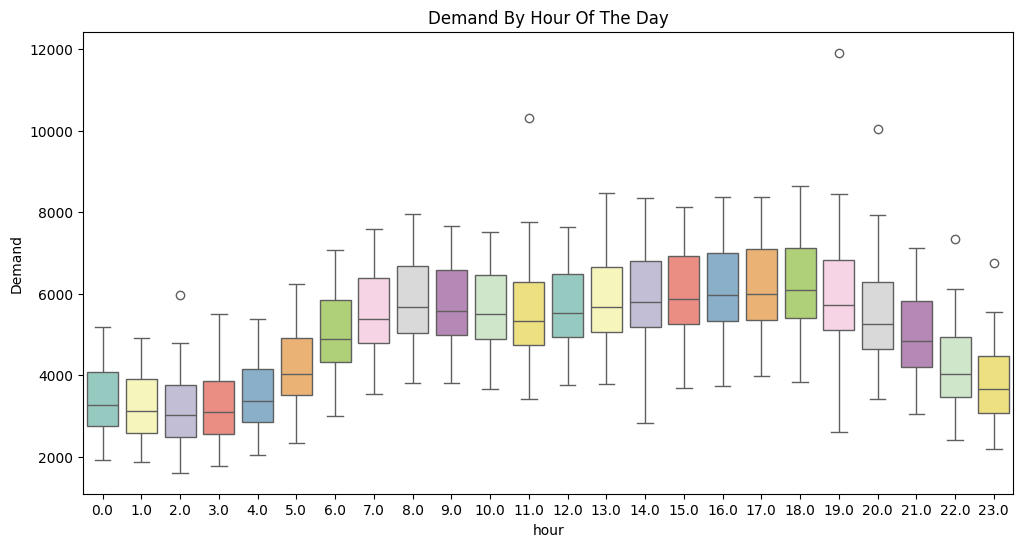

In [58]:
# Visualize demand by hour of day, using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='hour', y='Demand', palette='Set3')
plt.title("Demand By Hour Of The Day")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_16956\3308786181.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = 'month', y = 'Demand',palette="coolwarm")


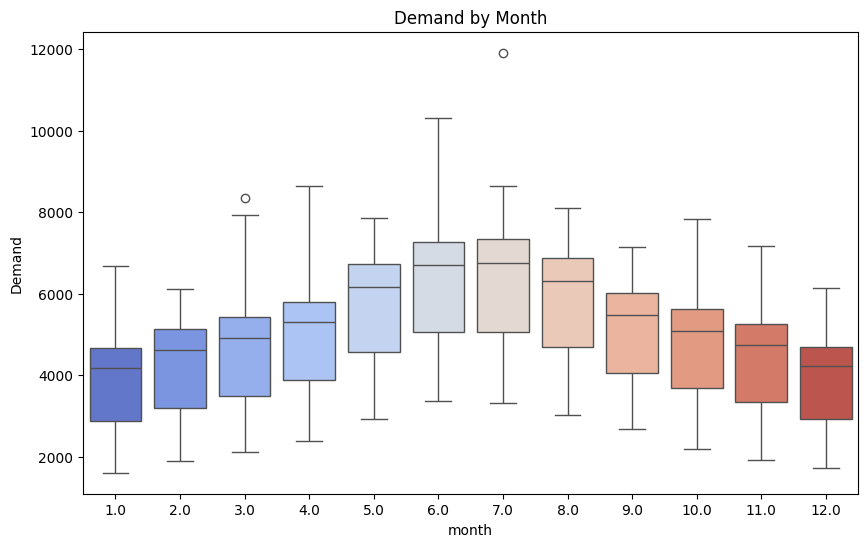

In [59]:
# Visualize demand by month, using boxplot

plt.figure(figsize=(10,6))
sns.boxplot(data = data, x = 'month', y = 'Demand',palette="coolwarm")
plt.title("Demand by Month")
plt.show()

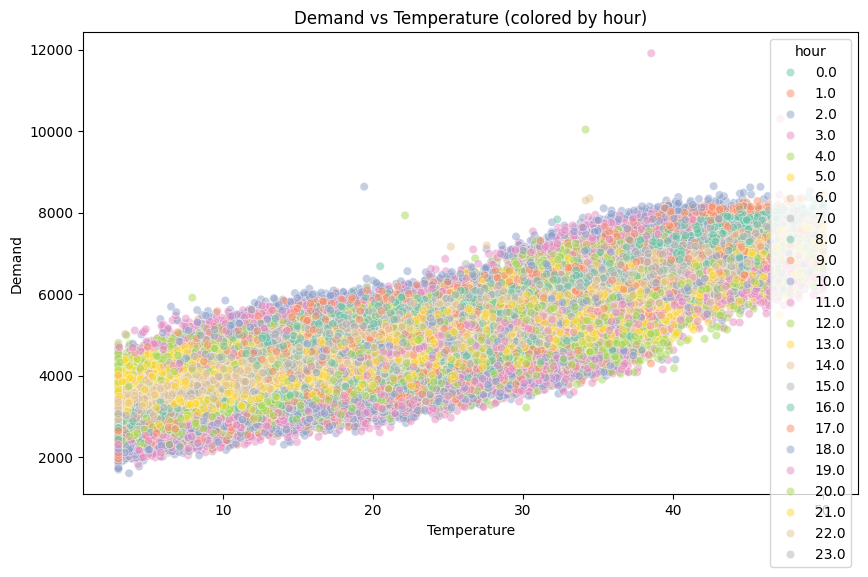

In [61]:
# Scatter plot of Demand vs. Temperature
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Temperature', y='Demand', hue='hour', alpha=0.5, palette='Set2')
plt.title("Demand vs Temperature (colored by hour)")
plt.show()


In [62]:
data.corr()

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
hour,1.000000,-0.000115,0.000180,0.000102,0.000171,0.000178,0.000184,-0.000209,0.051951,-0.293458,0.396125,0.396106,0.396643,0.000259,0.006970,0.000232,0.000044
dayofweek,-0.000115,1.000000,0.001075,-0.001110,0.001074,0.000205,0.002582,0.790556,-0.000997,-0.002241,-0.127264,-0.000160,-0.127111,-0.096577,-0.038909,-0.000013,0.000281
month,0.000180,0.001075,1.000000,-0.008866,0.996483,0.971869,0.971288,-0.001224,-0.014012,0.597453,0.030413,0.038570,0.085669,0.055634,-0.009339,0.095999,0.032341
year,0.000102,-0.001110,-0.008866,1.000000,-0.009407,-0.020163,-0.007481,0.000965,-0.005114,-0.000723,0.046536,0.046309,0.046448,0.074864,-0.000530,0.077436,0.005422
dayofyear,0.000171,0.001074,0.996483,-0.009407,1.000000,0.973509,0.968174,-0.001039,-0.016933,0.596751,0.028207,0.036378,0.083606,0.052103,-0.012311,0.092541,0.027375
weekofyear,0.000178,0.000205,0.971869,-0.020163,0.973509,1.000000,0.947413,0.000236,-0.025676,0.596420,0.021370,0.028823,0.076420,0.040529,-0.023232,0.080666,0.014119
quarter,0.000184,0.002582,0.971288,-0.007481,0.968174,0.947413,1.000000,0.001131,-0.011304,0.614172,0.033021,0.041309,0.087848,0.059945,-0.004356,0.100669,0.034597
is_weekend,-0.000209,0.790556,-0.001224,0.000965,-0.001039,0.000236,0.001131,1.000000,-0.001066,-0.001308,-0.160328,-0.047939,-0.160181,-0.162678,-0.144246,0.000146,0.000138
Temperature,0.051951,-0.000997,-0.014012,-0.005114,-0.016933,-0.025676,-0.011304,-0.001066,1.000000,0.001396,0.828224,0.804329,0.796066,0.772259,0.568849,0.789083,0.738527
Humidity,-0.293458,-0.002241,0.597453,-0.000723,0.596751,0.596420,0.614172,-0.001308,0.001396,1.000000,-0.066263,-0.077865,-0.031595,0.069103,0.002229,0.108363,0.042220


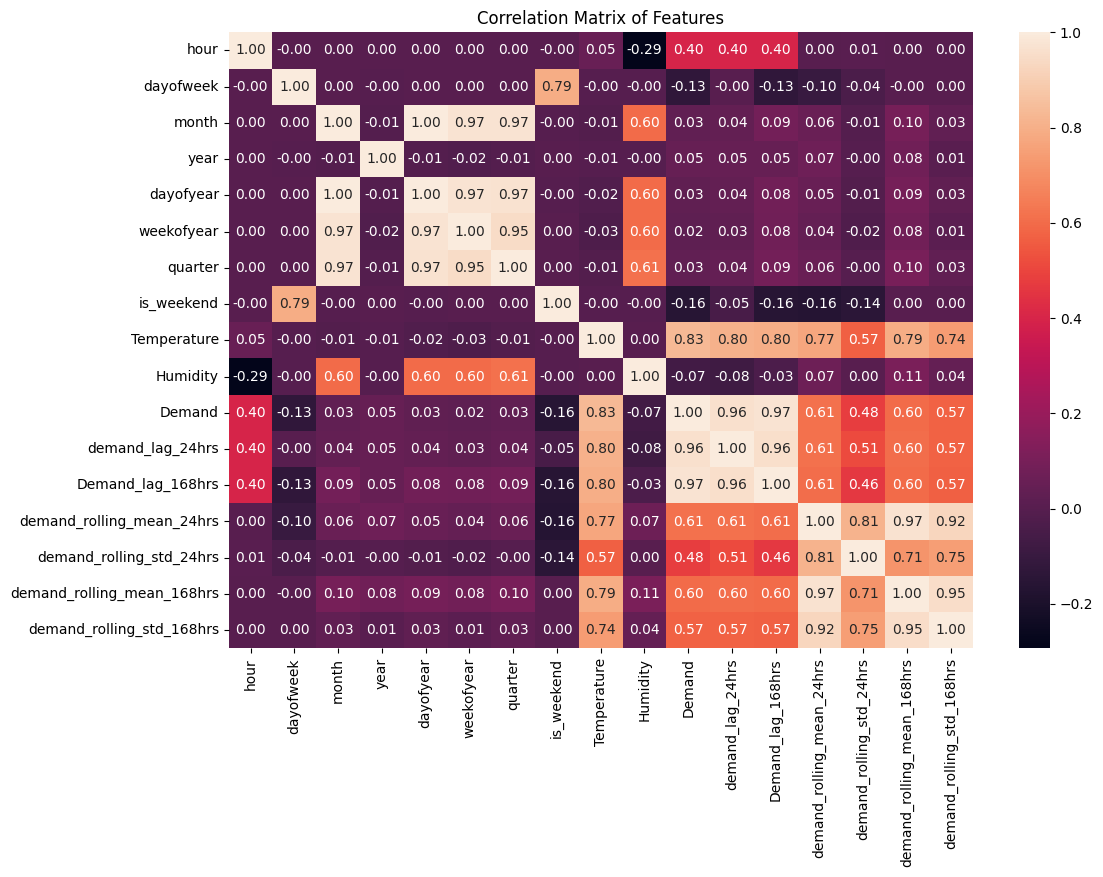

In [63]:
# Correlation Matrix and Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot = True, fmt=".2f") # anoot=True : to show the numbers , fmt : to adjust decimals
plt.title("Correlation Matrix of Features")
plt.show()

In [64]:
data

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,Demand,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,,
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968,3737.113310,974.096125
2020-01-08,1.0,2.0,1.0,2020.0,8.0,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101,3737.188632,973.982477
2020-01-08,2.0,2.0,1.0,2020.0,8.0,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351,3737.055797,974.192732
2020-01-08,3.0,2.0,1.0,2020.0,8.0,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212,3737.261108,973.864974
2020-01-08,4.0,2.0,1.0,2020.0,8.0,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905,3736.845382,974.422879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312,3939.391474,973.246610
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615,3937.353242,972.057461
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114,3938.303367,972.055830


In [65]:
# Defining Target Variable (Y)
Y=data.Demand                # target variable / dependent variable

In [66]:
# Defining Features (X)
X= data.drop('Demand', axis=1)               # independent variables / features / predictors

In [67]:
print(Y)

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 43676, dtype: float64


In [68]:
# print(X)
X               #Features

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968,3737.113310,974.096125
2020-01-08,1.0,2.0,1.0,2020.0,8.0,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101,3737.188632,973.982477
2020-01-08,2.0,2.0,1.0,2020.0,8.0,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351,3737.055797,974.192732
2020-01-08,3.0,2.0,1.0,2020.0,8.0,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212,3737.261108,973.864974
2020-01-08,4.0,2.0,1.0,2020.0,8.0,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905,3736.845382,974.422879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312,3939.391474,973.246610
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615,3937.353242,972.057461
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114,3938.303367,972.055830


In [69]:
# Splitting the data into Training and Testing data
# taking 80% of data as training data
X_train = X.loc[ :'2023-12-31']

In [70]:
X_train

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2216.875986,2457.119872,3857.890516,1007.130968,3737.113310,974.096125
2020-01-08,1.0,2.0,1.0,2020.0,8.0,2,1,0,4.433666,61.209727,2400.102433,2269.904712,3852.992863,1014.785101,3737.188632,973.982477
2020-01-08,2.0,2.0,1.0,2020.0,8.0,2,1,0,5.000529,63.868618,2493.107375,2215.640403,3840.501897,1033.916351,3737.055797,974.192732
2020-01-08,3.0,2.0,1.0,2020.0,8.0,2,1,0,4.253477,44.603210,2241.451559,2174.232413,3839.138277,1036.136212,3737.261108,973.864974
2020-01-08,4.0,2.0,1.0,2020.0,8.0,2,1,0,5.966044,85.921008,2406.161001,2472.453006,3838.990361,1036.349905,3736.845382,974.422879
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31,19.0,6.0,12.0,2023.0,365.0,52,4,1,6.721774,46.627264,3894.908251,3840.654680,3597.790591,879.089476,3904.956829,990.219481
2023-12-31,20.0,6.0,12.0,2023.0,365.0,52,4,1,7.557696,58.505012,3797.287793,4122.218903,3599.126925,879.430235,3903.213620,990.092487
2023-12-31,21.0,6.0,12.0,2023.0,365.0,52,4,1,3.000000,48.001079,3280.602315,3307.887152,3604.785551,877.726873,3903.859586,989.737091


In [71]:
Y_train = Y.loc[ : '2023-12-31' ]             # taking 80% of data as training data

In [72]:
Y_train

Timestamp
2020-01-08    2363.060115
2020-01-08    2282.558766
2020-01-08    2193.324174
2020-01-08    2208.724679
2020-01-08    2402.611018
                 ...     
2023-12-31    4185.721624
2023-12-31    3829.359810
2023-12-31    3416.409325
2023-12-31    3188.143951
2023-12-31    2631.860751
Name: Demand, Length: 34892, dtype: float64

In [73]:
X_test = X.loc[ '2024-01-01' : ]               # taking 20% of data as testing data

In [74]:
X_test            # 20% of the training features data  

,hour,dayofweek,month,year,dayofyear,weekofyear,quarter,is_weekend,Temperature,Humidity,demand_lag_24hrs,Demand_lag_168hrs,demand_rolling_mean_24hrs,demand_rolling_std_24hrs,demand_rolling_mean_168hrs,demand_rolling_std_168hrs
Timestamp,,,,,,,,,,,,,,,,
2024-01-01,0.0,0.0,1.0,2024.0,1.0,1,1,0,3.000000,65.297046,2373.967493,2752.003113,3626.185642,856.204515,3904.458526,989.377582
2024-01-01,1.0,0.0,1.0,2024.0,1.0,1,1,0,3.000000,69.068654,2328.972904,2419.747602,3640.380403,836.357296,3905.946024,987.317714
2024-01-01,2.0,0.0,1.0,2024.0,1.0,1,1,0,3.000000,80.885372,1729.176090,2292.834087,3669.813854,776.458065,3906.795695,985.981698
2024-01-01,3.0,0.0,1.0,2024.0,1.0,1,1,0,7.788675,66.501527,2257.337352,2507.704476,3685.801618,749.595470,3907.589381,984.901803
2024-01-01,4.0,0.0,1.0,2024.0,1.0,1,1,0,6.607828,57.858109,2516.948873,2690.933257,3692.926651,738.736316,3907.571622,984.923900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,5102.077310,5105.730509,4039.969992,976.961312,3939.391474,973.246610
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4187.844204,4673.672173,4045.945201,978.342615,3937.353242,972.057461
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,3859.260701,3856.359014,4052.475170,977.565114,3938.303367,972.055830


In [75]:
Y_test = Y.loc[ '2024-01-01' : ]                       # taking 20% of data as testing data

In [76]:
Y_test                                                 # 20% of the testing target variable

Timestamp
2024-01-01    2720.606072
2024-01-01    2669.647167
2024-01-01    2435.578924
2024-01-01    2641.043699
2024-01-01    2687.949643
                 ...     
2024-12-31    4689.693109
2024-12-31    4331.249224
2024-12-31    4015.979957
2024-12-31    3353.241682
2024-12-31    3219.023339
Name: Demand, Length: 8784, dtype: float64

In [77]:
print(X_train.shape)                   
print(Y_train.shape)

(34892, 16)
(34892,)


In [78]:
print(X_test.shape)
print(Y_test.shape)

(8784, 16)
(8784,)


In [79]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
from xgboost import XGBRegressor     # from XGBoost library we are importing XGBRegressor class
# from sklearn library importing two fundamental metrics to evaluate the performance of the model
from sklearn.metrics import mean_squared_error, mean_absolute_error

# from model_selection module of scikit-learn's library, import TimeSeriesSplit class
# TimeSeriesSplit class performs appropriate cross-validation when dealing with time series data
from sklearn.model_selection import TimeSeriesSplit

In [81]:
# Initialize and train the model

model_xgb = XGBRegressor(n_estimators = 1000,                
                         early_stopping_rounds = 50,
                         learning_rate = 0.01,
                         random_state = 42,
                         objective = 'reg:squarederror' )

In [82]:
# training the model

model_xgb.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [83]:
# Make predictions

predictions_xgb = model_xgb.predict(X_test)

In [84]:
# Evaluating the model

rmse_xgb = np.sqrt(mean_squared_error(Y_test, predictions_xgb))

mae_xgb = mean_absolute_error(Y_test, predictions_xgb )

In [85]:
print('XGBoost RMSE:',  rmse_xgb)
print('XGBoost MAE:' ,  mae_xgb)

XGBoost RMSE: 175.1432831986059
XGBoost MAE: 123.45883128679542


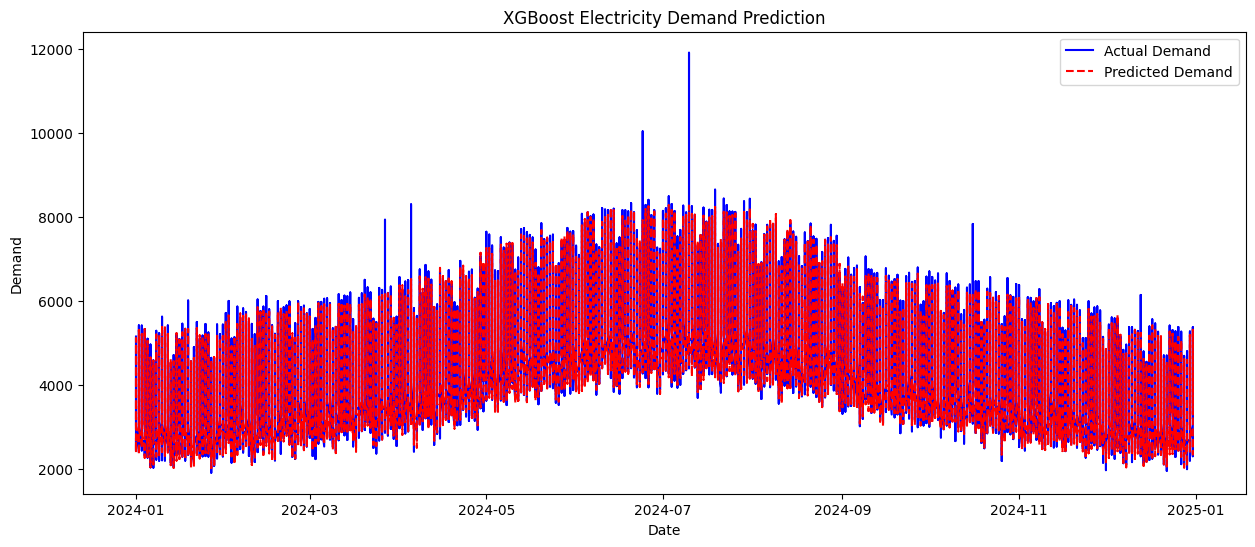

In [86]:
# Visulaize the Predictions

plt.figure(figsize = (15,6))
plt.plot(Y_test.index, Y_test, label = 'Actual Demand', color = 'Blue')
plt.plot(Y_test.index, predictions_xgb, label = 'Predicted Demand', color = 'Red', linestyle='--')
plt.title('XGBoost Electricity Demand Prediction')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()

plt.show()

In [87]:
# save the model

import joblib

joblib.dump(model_xgb, 'electicity_xgb_prediction_model.pkl')

['electicity_xgb_prediction_model.pkl']

In [88]:
# load and Use:

loaded_model = joblib.load('electicity_xgb_prediction_model.pkl')

# future_predictions = loaded_model.predict(X_future)

In [89]:
loaded_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)